## Import Library

In [64]:
import numpy as np
import cv2
import os
import random
from matplotlib import pyplot as plt
from scipy.spatial import distance

## Data loader
#### load data images and resize to (29, 41) and flatten into (1189)

In [65]:
class dataloader():
	def __init__(self, root_folder_path, mode = 'Training'):
		self.root_folder_path = root_folder_path
		self.images = []
		self.labels = []
		assert mode in ['Training', 'Testing']
		image_path = os.path.join(root_folder_path, mode)
		for file_name in os.listdir(image_path):
			if file_name.endswith('.pgm'):
				label = file_name.split('.')[0].replace('subject', '')
				label = int(label)
				
				file_path = os.path.join(image_path, file_name)
				image = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
				image = cv2.resize(image, (29, 41))
				image = image.flatten()
				self.labels.append(label)
				self.images.append(image)
	def get_data(self):
		return np.array(self.images), np.array(self.labels)

## Eigenfaces (PCA)

In [66]:
class Eigenfaces():
	def __init__(self, mode = 'normal', kernel_type = 'RBF'):
		assert mode in ['normal', 'kernel']
		self.mode = mode
		self.root_path = "Yale_Face_Database/"
		self.train_loader = dataloader(self.root_path, mode = 'Training')
		self.test_loader = dataloader(self.root_path, mode = 'Testing')
		self.train_x, self.train_y = self.train_loader.get_data()
		self.test_x, self.test_y = self.test_loader.get_data()
		self.kernel_type = None
		if self.mode == 'kernel':
			self.kernel_type = kernel_type
			self.K = self.get_kernel(self.train_x, self.train_x, kernel_type)
		self.mean = np.mean(self.train_x, axis=0)
		self.S = self.get_covariance()
	def get_covariance(self):
		if self.mode == 'normal':
			cov_matrix = (self.train_x - self.mean).T @ \
				(self.train_x - self.mean) / (self.train_x.shape[0])
		elif self.mode == 'kernel':
			n = self.K.shape[0]
			N = np.full((n, n), 1 / n)
			cov_matrix = self.K - N @ self.K - self.K @ N + N @ self.K @ N
		return cov_matrix
	def PCA(self):
		eigen_values, eigen_vectors = self.compute_eig(self.S)
		sorted_indices = np.argsort(-1 * eigen_values)
		sorted_eigen_values = eigen_values[sorted_indices]
		sorted_eigen_vectors = eigen_vectors[:, sorted_indices]
		self.W = sorted_eigen_vectors.real
		if self.mode == 'kernel':
			sorted_eigen_values = np.clip(sorted_eigen_values, 1e-8, None)
			self.W = self.W / np.sqrt(sorted_eigen_values)
	def show_eigenface(self):
		grid_size = (5, 5)
		fig, axes = plt.subplots(*grid_size, figsize=(5, 5), sharex=True, sharey=True)
		for i, ax in enumerate(axes.flat):
			face = self.W[:, i].reshape(41, 29)
			ax.imshow(face, cmap='gray')
			ax.axis('off')
		plt.tight_layout()
		plt.show()
	def reconstruct_faces(self):
		selected_indices = random.sample(range(135), 10)
		selected_imgs = self.train_x[selected_indices, :]
		W = self.W[:, :25]
		y = (selected_imgs - self.mean) @ W
		reconstructed_faces = y @ W.T + self.mean
		# plot reconstruct
		grid_size = (2, 10)
		fig, axes = plt.subplots(*grid_size, figsize=(4, 3), sharex=True, sharey=True)
		for i in range(10):
			ori_face = selected_imgs[i, :].reshape(41, 29)
			recon_face = reconstructed_faces[i, :].reshape(41, 29)
			axes[0, i].imshow(ori_face, cmap='gray')
			axes[1, i].imshow(recon_face, cmap='gray')
			axes[0, i].axis('off')
			axes[1, i].axis('off')
		plt.subplots_adjust(wspace=0, hspace=0)
		plt.tight_layout(pad=0)
		plt.show()
	def predict_test_x(self):
		K = 7
		W = self.W[:, :25]
		if self.mode == 'normal':
			train_y = (self.train_x - self.mean) @ W
			test_y = (self.test_x - self.mean) @ W
		elif self.mode == 'kernel':
			train_k = self.get_kernel(self.train_x, self.train_x, self.kernel_type)
			test_k = self.get_kernel(self.test_x, self.train_x, self.kernel_type)
			train_y = train_k @ W
			test_y = test_k @ W
		distances = distance.cdist(test_y, train_y, metric='euclidean')
		predictions = []
		for i in range(len(test_y)):
			k_indices = np.argsort(distances[i])[:K]
			k_nearest_labels = [self.train_y[j] for j in k_indices]
			most_common = np.bincount(k_nearest_labels).argmax()
			predictions.append(most_common)
		predictions = np.array(predictions)
		accuracy = np.mean(predictions == self.test_y)
		print(f"Accuracy: {accuracy * 100:.2f}%")
	def get_kernel(self, Xa, Xb, kernel_type):
		gamma = 1e-10
		alpha = 1e-3
		coef0 = 1
		degree = 2
		if kernel_type == 'RBF':
			square_norm = distance.cdist(Xa, Xb, metric='sqeuclidean')
			return np.exp(-gamma * square_norm)
		elif kernel_type == 'poly':
			return (alpha * Xa @ Xb.T + coef0) ** degree
	def compute_eig(self, S):
		eigenvalues, eigenvectors = np.linalg.eig(S)
		return eigenvalues, eigenvectors

## Experiment (normal)

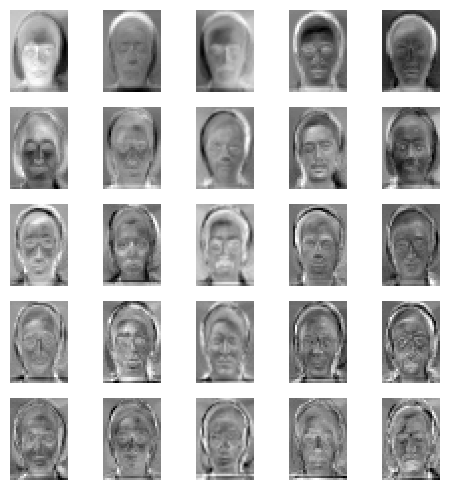

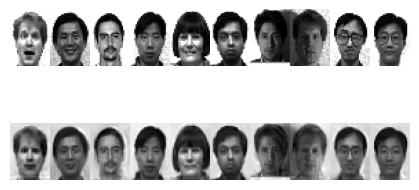

Accuracy: 90.00%


In [67]:
normal = Eigenfaces()
normal.PCA()
normal.show_eigenface()
normal.reconstruct_faces()
normal.predict_test_x()

## Experiment (Kernel)

In [68]:
kernel_RBF = Eigenfaces(mode = 'kernel', kernel_type = 'RBF')
kernel_RBF.PCA()
kernel_RBF.predict_test_x()

Accuracy: 90.00%


In [69]:
kernel_poly = Eigenfaces(mode = 'kernel', kernel_type = 'poly')
kernel_poly.PCA()
kernel_poly.predict_test_x()


Accuracy: 90.00%


## Fisherfaces (LDA)

In [70]:
class Fisherface():
	def __init__(self, mode = 'normal', kernel_type = 'RBF'):
		assert mode in ['normal', 'kernel']
		self.mode = mode
		self.root_path = "Yale_Face_Database/"
		self.train_loader = dataloader(self.root_path, mode = 'Training')
		self.test_loader = dataloader(self.root_path, mode = 'Testing')
		self.train_x, self.train_y = self.train_loader.get_data()
		self.test_x, self.test_y = self.test_loader.get_data()
		self.kernel_type = None
		self.overall_mean = np.mean(self.train_x, axis=0)
		self.class_means = self.get_class_means()
		if self.mode == 'kernel':
			self.kernel_type = kernel_type
			self.K = self.get_kernel(self.train_x, self.train_x, self.kernel_type)
			self.S_W  = self.get_N()
			self.S_B = self.get_M()
		elif self.mode == 'normal':
			self.S_W = self.get_within_class_scatter()
			self.S_B = self.get_between_class_scatter()
	def get_class_means(self):
		class_means = []
		for i in range(1, 16):
			class_indices = np.where(self.train_y == i)[0]
			class_mean = np.mean(self.train_x[class_indices, :], axis=0)
			class_means.append(class_mean.flatten())
		return np.array(class_means)
	def get_within_class_scatter(self):
		S_W = np.zeros((self.train_x.shape[1], self.train_x.shape[1]))
		for i in range(1, 16):
			class_indices = np.where(self.train_y == i)[0]
			class_mean = self.class_means[i - 1]
			class_x = self.train_x[class_indices, :]
			class_scatter = (class_x - class_mean).T @ (class_x - class_mean)
			S_W += class_scatter
		return S_W
	def get_between_class_scatter(self):
		S_B = np.zeros((self.train_x.shape[1], self.train_x.shape[1]))
		for i in range(1, 16):
			class_mean = self.class_means[i - 1]
			n_i = np.sum(self.train_y == i)
			S_B += n_i * np.outer((class_mean - self.overall_mean),
						(class_mean - self.overall_mean))
		return S_B
	def LDA(self):
		eigen_values, eigen_vectors = self.compute_eig(self.S_W, self.S_B)
		sorted_indices = np.argsort(-1 * eigen_values)
		sorted_eigen_values = eigen_values[sorted_indices]
		sorted_eigen_vectors = eigen_vectors[:, sorted_indices]
		self.W = sorted_eigen_vectors.real
	def show_fisherface(self):
		grid_size = (5, 5)
		fig, axes = plt.subplots(*grid_size, figsize=(5, 5), sharex=True, sharey=True)
		for i, ax in enumerate(axes.flat):
			if self.mode == 'normal':
				face = (self.W[:, i]).reshape(41, 29)
			else:
				face = self.W[:, i].reshape(41, 29)
			ax.imshow(face, cmap='gray')
			ax.axis('off')
		plt.tight_layout()
		plt.show()
	def reconstruct_faces(self):
		selected_indices = random.sample(range(135), 10)
		selected_imgs = self.train_x[selected_indices, :]
		W = self.W[:, :25]
		y = (selected_imgs -  self.overall_mean)@ W
		reconstructed_faces = y @ W.T
		# plot reconstruct
		grid_size = (2, 10)
		fig, axes = plt.subplots(*grid_size, figsize=(4, 3), sharex=True, sharey=True)
		for i in range(10):
			ori_face = selected_imgs[i, :].reshape(41, 29)
			recon_face = reconstructed_faces[i, :].reshape(41, 29)
			axes[0, i].imshow(ori_face, cmap='gray')
			axes[1, i].imshow(recon_face, cmap='gray')
			axes[0, i].axis('off')
			axes[1, i].axis('off')
		plt.subplots_adjust(wspace=0, hspace=0)
		plt.tight_layout(pad=0)
		plt.show()
	def predict_test_x(self):
		K = 7
		W = self.W[:, :25]
		if self.mode == 'normal':
			train_y = (self.train_x - self.overall_mean) @ W
			test_y = (self.test_x - self.overall_mean)@ W
		elif self.mode == 'kernel':
			train_k = self.get_kernel(self.train_x, self.train_x, self.kernel_type)
			test_k = self.get_kernel(self.test_x, self.train_x, self.kernel_type)
			train_y = train_k @ W
			test_y = test_k @ W
		distances = distance.cdist(test_y, train_y, metric='euclidean')
		predictions = []
		for i in range(len(test_y)):
			k_indices = np.argsort(distances[i])[:K]
			k_nearest_labels = [self.train_y[j] for j in k_indices]
			most_common = np.bincount(k_nearest_labels).argmax()
			predictions.append(most_common)
		predictions = np.array(predictions)
		accuracy = np.mean(predictions == self.test_y)
		print(f"Accuracy: {accuracy * 100:.2f}%")
	def get_kernel(self, Xa, Xb, kernel_type):
		gamma = 1e-10
		alpha = 1e-10
		coef0 = 2
		degree = 3
		if kernel_type == 'RBF':
			square_norm = distance.cdist(Xa, Xb, metric='sqeuclidean')
			return np.exp(-gamma * square_norm)
		elif kernel_type == 'poly':
			return (alpha * Xa @ Xb.T + coef0) ** degree
	def get_N(self):
		N = np.zeros((self.train_x.shape[0], self.train_x.shape[0]))
		for label in self.train_y:
			idx = np.where(self.train_y == label)[0]
			Ki = self.K[:, idx]
			N += Ki @ (np.eye(9) - np.full((9), 1/9)) @ Ki.T
		N += np.eye(self.train_x.shape[0]) * 1e-6
		return N
	def get_M(self):
		M = np.zeros((self.train_x.shape[0], self.train_x.shape[0]))
		M_star = np.sum(self.K, axis=1)
		M_star = M_star.reshape(-1, 1)
		M_star = M_star / 9
		for label in self.train_y:
			idx = np.where(self.train_y == label)[0]
			Ki = self.K[:, idx]
			M_c = np.sum(Ki, axis=1)
			M_c = M_c.reshape(-1, 1)
			M_c = M_c / 9
			M += 9 * (M_c - M_star) @ (M_c - M_star).T
		return M
	def compute_eig(self, S_W, S_B):
		if self.mode == 'normal':
			eigenvalues, eigenvectors = np.linalg.eig(np.linalg.inv(S_W + 1e-8 * np.eye(self.train_x.shape[1])) @ S_B)
		elif self.mode == 'kernel':
			eigenvalues, eigenvectors = np.linalg.eig(np.linalg.inv(S_W + 1e-8 * np.eye(self.train_x.shape[0])) @ S_B)
		return eigenvalues, eigenvectors

## Experiment (Fisherfaces)

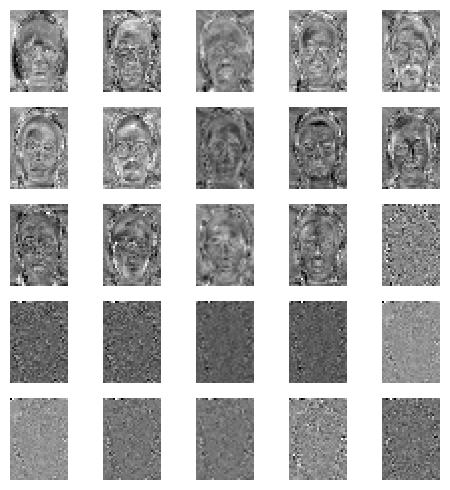

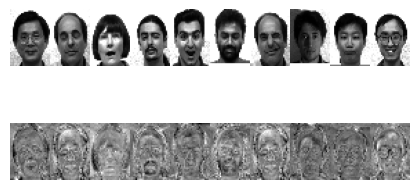

Accuracy: 100.00%


In [71]:
LDA = Fisherface()
LDA.LDA()
LDA.show_fisherface()
LDA.reconstruct_faces()
LDA.predict_test_x()

## Experiment (Kernel Fisherfaces)

In [72]:
KDA_RBF = Fisherface(mode = 'kernel', kernel_type = 'RBF')
KDA_RBF.LDA()
KDA_RBF.predict_test_x()

Accuracy: 100.00%


In [73]:
KDA_poly = Fisherface(mode = 'kernel', kernel_type = 'poly')
KDA_poly.LDA()
KDA_poly.predict_test_x()

Accuracy: 93.33%
